# Install and import Libraries

In [1]:
! pip install ultralytics easyocr hezar insightface onnxruntime

In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import os
import pandas as pd
import re
from hezar.models import Model
from insightface.app import FaceAnalysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Read kibord dataset

In [ ]:
import gdown
import zipfile
import os

In [ ]:
file_id = "1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM"
dataset_zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

In [ ]:
gdown.download(f"https://drive.google.com/uc?id={file_id}", dataset_zip_path, quiet=False)

with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset downloaded and extracted successfully!")


Downloading...
From (original): https://drive.google.com/uc?id=1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM
From (redirected): https://drive.google.com/uc?id=1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM&confirm=t&uuid=6f05fa74-3d7e-462a-99b3-fd8490a30692
To: /content/dataset.zip
100%|██████████| 539M/539M [00:10<00:00, 52.7MB/s]


✅ Dataset downloaded and extracted successfully!


In [ ]:
print("Sample files:", os.listdir(extract_path)[:5])

Sample files: ['2832.PNG', '1443.jpg', '650.PNG', '5.PNG', '1601.jpg']


Cloning into 'NationalCard-ImageProccessing'...
remote: Enumerating objects: 489, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 489 (delta 30), reused 7 (delta 5), pack-reused 432 (from 2)
Receiving objects: 100% (489/489), 110.49 MiB | 28.35 MiB/s, done.
Resolving deltas: 100% (119/119), done.


# Set model and path

In [4]:
!git clone https://github.com/cactus1386/NationalCard-ImageProccessing.git
detector = FaceAnalysis(name='buffalo_l')
detector.prepare(ctx_id=0, det_size=(640, 640))
objects_model = YOLO('/content/NationalCard-ImageProccessing/weight/TextDetection.pt') # set yolo model for object detection
card_model = YOLO('/content/NationalCard-ImageProccessing/weight/CardDetection.pt') # set yolo model for card detection
hezar_ocr = Model.load("hezarai/crnn-fa-printed-96-long") # set hezar ocr model
rotate_idcard_model = YOLO('/content/NationalCard-ImageProccessing/weight/RotateIDCard.pt')

Cloning into 'NationalCard-ImageProccessing'...
remote: Enumerating objects: 489, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 489 (delta 30), reused 7 (delta 5), pack-reused 432 (from 2)
Receiving objects: 100% (489/489), 110.49 MiB | 25.87 MiB/s, done.
Resolving deltas: 100% (119/119), done.
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 79355.06KB/s]
/usr/local/lib/python3.11/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_config.yaml:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.pt:   0%|          | 0.00/37.2M [00:00<?, ?B/s]

image_processor_config.yaml:   0%|          | 0.00/153 [00:00<?, ?B/s]

# Rotation Code

In [6]:
def rotation(path):
    image = cv2.imread(path) # set image
    results = card_model(image) # run card yolo model for image

    if len(results[0].boxes) == 0: # if cant recognize card
        print("No card detected!")
        return None

    # set 4 corner location
    x1, y1, x2, y2 = map(int, results[0].boxes[0].xyxy[0])
    cropped_card = image[y1:y2, x1:x2]

    # detect face in the cropped card
    faces = detector.get(cropped_card)

    # check for faces
    if faces:
        x1, y1, x2, y2 = map(int, faces[0]['bbox'])  # Get face bounding box
        w, h = x2 - x1, y2 - y1
        face_center = (x1 + w // 2, y1 + h // 2)  # Face center
        card_center = (cropped_card.shape[1] // 2, cropped_card.shape[0] // 2)  # Card center

        # calculate rotation angle
        angle = np.arctan2(face_center[1] - card_center[1], face_center[0] - card_center[0]) * (180 / np.pi) + 180
        rotation_matrix = cv2.getRotationMatrix2D(card_center, angle, 1.0)
        rotated = cv2.warpAffine(cropped_card, rotation_matrix, (cropped_card.shape[1], cropped_card.shape[0]))

        return rotated  # return image

    return cropped_card  # if cant find face


In [9]:
def rotate_idcard(image_path):
  import cv2
  import math
  import numpy as np
  from google.colab.patches import cv2_imshow

  image = cv2.imread(image_path) # set image
  results = card_model(image) # run card yolo model for image

  if len(results[0].boxes) == 0: # if cant recognize card
      print("No card detected!")
      return None

    # set 4 corner location
  x1, y1, x2, y2 = map(int, results[0].boxes[0].xyxy[0])
  cropped_card = image[y1:y2, x1:x2]


  r = rotate_idcard_model.predict(source=cropped_card, show=False, conf=0.5)

  result = r[0]
  boxes = result.boxes.xyxy.cpu().numpy().astype(int)
  confidences = result.boxes.conf.cpu().numpy()
  class_ids = result.boxes.cls.cpu().numpy().astype(int)
  class_names = result.names

  image = cropped_card


  flag_x1, flag_y1, flag_x2, flag_y2 = boxes[0]
  flag_center_x = (flag_x1 + flag_x2) // 2
  flag_center_y = (flag_y1 + flag_y2) // 2


  flag_class_id = class_ids[0]
  flag_class_name = class_names[flag_class_id]


  logo_x1, logo_y1, logo_x2, logo_y2 = boxes[1]
  logo_center_x = (logo_x1 + logo_x2) // 2
  logo_center_y = (logo_y1 + logo_y2) // 2

  logo_class_id = class_ids[1]
  logo_class_name = class_names[logo_class_id]

  cv2.rectangle(image, (flag_x1, flag_y1), (flag_x2, flag_y2), (0, 255, 0), 2)
  cv2.putText(image, flag_class_name, (flag_x1, flag_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
  cv2.circle(image, (flag_center_x, flag_center_y), 5, (0, 255, 0), -1)

  cv2.rectangle(image, (logo_x1, logo_y1), (logo_x2, logo_y2), (255, 0, 0), 2)
  cv2.putText(image, logo_class_name, (logo_x1, logo_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
  cv2.circle(image, (logo_center_x, logo_center_y), 5, (255, 0, 0), -1)


  slope = (logo_center_y - flag_center_y) / (logo_center_x - flag_center_x)
  angle = np.arctan(slope)
  rotation_angle = np.degrees(angle)

  center = (image.shape[1] // 2, image.shape[0] // 2)


  rotation_matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
  rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))



  return(rotated_image)

# Use other model for text detection (Hezar)

In [7]:
def process_img(img):
    data = {}
    results = objects_model(img) # set part of object detection yolo model

    # dict for each box conf
    box_confidences = {}

    for result in results:
        boxes = result.boxes
        for box in boxes:
            xyxy = box.xyxy[0]
            x1, y1, x2, y2 = map(int, xyxy.tolist()) # set corner locations
            label = result.names[int(box.cls)] # set label
            conf = float(box.conf)  # set conf

            cropped_img = img[max(0, y1-3):y2+3, max(0, x1-3):x2+3] # cropped image location (with more nums for better conf)
            cv2_imshow(cropped_img)

            ocr_result = hezar_ocr.predict(cropped_img)  # read text with ocr

            if ocr_result:  # check if OCR returned results
                text_list = []
                for item in ocr_result:
                    text_list.append(item['text'])
                text = " ".join(text_list)  # retrun text
            else:
                text = "" # return empty str

            # best conf text (if have more than one)
            if label in box_confidences:
                if conf > box_confidences[label][1]:
                    box_confidences[label] = (text, conf)
            else:
                box_confidences[label] = (text, conf)

    # print label, text and conf
    for label, (text, conf) in box_confidences.items():
        print(f"Label: {label}, Text: {text}, Confidence: {conf}")
        data[label] = text.strip()

    return data

# Call function and use it

In [15]:
def detect(folder):
    detected = [] # set empty list
    for img in os.listdir(folder):
      # get images from folder and set csv columns
        if img.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.heic')):
            img_path = os.path.join(folder, img)
            data = {'image_id': img.split('.')[0], 'national_id': '', 'first_name': '', 'last_name': '',
                    'birth_year': '', 'birth_month': '', 'birth_day': '', 'father_name': '',
                    'expiry_year': '', 'expiry_month': '', 'expiry_day': ''}

            # rotation and crop card
            card = rotate_idcard(img_path)
            if card is None:
                continue

            # extract data from cropped image
            extracted_data = process_img(card)


            # set data in dict and in csv
            for key, value in extracted_data.items():
                value = re.sub(r'\s+', ' ', value).strip() # delete space from value (we have no white space in texts)
                if key == 'Expire': # set expiry date value in dict
                    try:
                        y, m, d = value.split('/') # splite to year, month and day
                        data['expiry_year'], data['expiry_month'], data['expiry_day'] = y, m, d # set expiry day, month and year
                    except ValueError:# if cant detect "/" well and get error
                        print(f"Error splitting Expire: {value}")
                elif key == 'Birth': # set birth date value in dict
                    try:
                        y, m, d = value.split('/') # splite to year, month and day
                        data['birth_year'], data['birth_month'], data['birth_day'] = y, m, d # set birth day, month and year
                    except ValueError: # if cant detect "/" well and get error
                        print(f"Error splitting Birth: {value}")
                elif key == 'National': # set national id value in dict
                    data['national_id'] = value
                elif key == 'Name': # set name value in dict
                    data['first_name'] = value
                elif key == 'LastName': # set last name value in dict
                    data['last_name'] = value
                elif key == 'FatherName': # set father name value in dict
                    data['father_name'] = value

            detected.append(data)

    pd.DataFrame(detected).to_csv('image_phase2.csv', index=False, encoding='utf-8')
    return detected


0: 480x640 1 Card, 13.2ms
Speed: 3.3ms preprocess, 13.2ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Flag, 1 Logo, 48.7ms
Speed: 2.6ms preprocess, 48.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


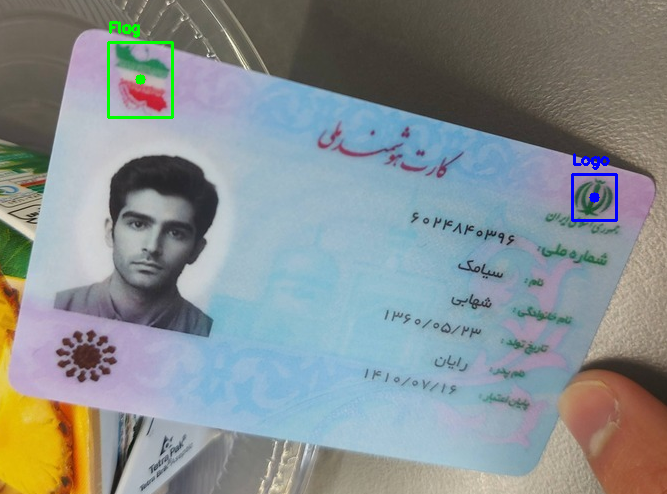


0: 480x640 1 Birth, 1 Expire, 1 FatherName, 1 LastName, 1 Name, 1 National, 17.0ms
Speed: 6.6ms preprocess, 17.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


Label: Expire, Text: نآااا, Confidence: 0.8540088534355164
Label: LastName, Text: شهابی, Confidence: 0.8447853922843933
Label: National, Text: ۶۰۲۴۸۴۰۳۹۶, Confidence: 0.8026525974273682
Label: Name, Text: سیامک, Confidence: 0.7786933183670044
Label: FatherName, Text: ابا, Confidence: 0.7739433646202087
Label: Birth, Text: ۱۶۰/۰۵/۲۳, Confidence: 0.7469784021377563
Error splitting Expire: نآااا


[{'image_id': '5',
  'national_id': '۶۰۲۴۸۴۰۳۹۶',
  'first_name': 'سیامک',
  'last_name': 'شهابی',
  'birth_year': '۱۶۰',
  'birth_month': '۰۵',
  'birth_day': '۲۳',
  'father_name': 'ابا',
  'expiry_year': '',
  'expiry_month': '',
  'expiry_day': ''}]

In [16]:
detect('/content/data')

# Sort csv

In [17]:
df = pd.read_csv('image_phase2.csv')
df = df.sort_values(by='image_id')
df.to_csv("image_phase2.csv", index=False)

In [18]:
df

,image_id,national_id,first_name,last_name,birth_year,birth_month,birth_day,father_name,expiry_year,expiry_month,expiry_day
0,5,۶۰۲۴۸۴۰۳۹۶,سیامک,شهابی,۱۶۰,۰۵,۲۳,ابا,NaN,NaN,NaN
